In [1]:
import os
import sys

# Always anchor relative to THIS file's location
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)
    #sys.path.insert(0, src_path)

import numpy as np
import torch
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import subprocess

src = os.path.join(project_root, "src")

scripts = ["data_generation.py", "ml_model.py"]

for script in scripts:
    path = os.path.join(src, script)
    result = subprocess.run(["python", path])
    
    if result.returncode != 0:
        print(f"{script} failed!")


#!python ../src/data_generation.py
#!python ../src/ml_model.py

0
R is : 0.4
R is : 0.4161616161616162
R is : 0.43232323232323233
R is : 0.4484848484848485
R is : 0.46464646464646464
R is : 0.4808080808080808
R is : 0.496969696969697
R is : 0.5131313131313131
R is : 0.5292929292929294
R is : 0.5454545454545454
R is : 0.5616161616161617
R is : 0.5777777777777778
R is : 0.593939393939394
R is : 0.6101010101010101
R is : 0.6262626262626263
R is : 0.6424242424242425
R is : 0.6585858585858586
R is : 0.6747474747474748
R is : 0.6909090909090909
R is : 0.7070707070707071
R is : 0.7232323232323232
R is : 0.7393939393939395
R is : 0.7555555555555555
R is : 0.7717171717171718
R is : 0.7878787878787878
R is : 0.8040404040404041
R is : 0.8202020202020202
R is : 0.8363636363636364
R is : 0.8525252525252526
R is : 0.8686868686868687
R is : 0.8848484848484849
R is : 0.901010101010101
R is : 0.9171717171717172
R is : 0.9333333333333333
R is : 0.9494949494949495
R is : 0.9656565656565657
R is : 0.9818181818181818
R is : 0.997979797979798
R is : 1.014141414141414
R 

MLPRegressor loaded successfully!
12


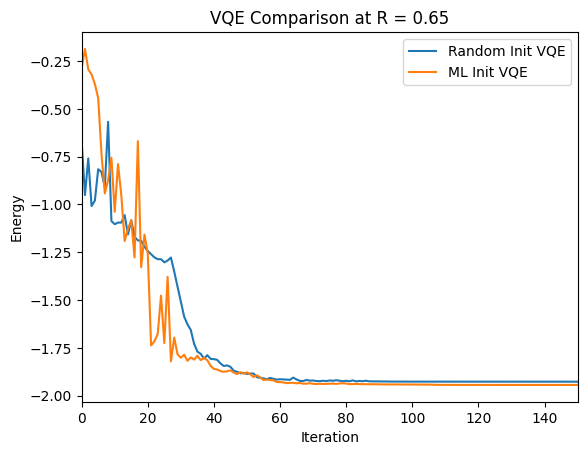

In [8]:
import os
import joblib
from vqe import ansatz
from vqe_tracking import run_vqe_with_tracking
from hamiltonian import generate_hamiltonian

BASE_DIR = os.getcwd() 

DATA_DIR = os.path.normpath(os.path.join(BASE_DIR, '..', 'data'))
MODEL_FILE = os.path.join(DATA_DIR, 'sklearn_model.joblib')

# 3. Load the model
if os.path.exists(MODEL_FILE):
    model = joblib.load(MODEL_FILE)
    print("MLPRegressor loaded successfully!")
else:
    print(f"Could not find model at: {MODEL_FILE}")

R_test = 0.65
H_test = generate_hamiltonian(R_test) 
ansatz.num_qubits = H_test.num_qubits

theta_random = np.random.uniform(0, 2*np.pi, ansatz.num_parameters)
print(ansatz.num_parameters)

baseline_energies, baseline_result = run_vqe_with_tracking(
    H_test,
    theta_random
)
theta_ml = model.predict([[R_test]])[0]
ml_energies, ml_result = run_vqe_with_tracking(
    H_test,
    theta_ml
)
import matplotlib.pyplot as plt

plt.plot(baseline_energies, label="Random Init VQE")
plt.plot(ml_energies, label="ML Init VQE")

plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.xlim(0, 150)
plt.title(f"VQE Comparison at R = {R_test}")
plt.legend()

plt.show()